In [1]:
!pip install torchinfo

In [2]:
!pip install lightly
!pip install torch-optimizer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="UnsupportedFieldAttributeWarning")

In [4]:
import os
import time
import copy
import json
import random
import platform
import csv
import psutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import PIL
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
from lightly.loss import NegativeCosineSimilarity
from lightly.models.modules.heads import (
    BYOLPredictionHead,
    BYOLProjectionHead,
)
from lightly.models.utils import deactivate_requires_grad, update_momentum
from lightly.transforms.byol_transform import (
    BYOLTransform,
    BYOLView1Transform,
    BYOLView2Transform,
)
from lightly.utils.scheduler import cosine_schedule
from lightly.transforms.multi_view_transform import MultiViewTransform
from lightly.transforms.torchvision_v2_compatibility import (
    torchvision_transforms as T,
)
from lightly.transforms.utils import IMAGENET_NORMALIZE
from torch_optimizer import LARS


This section checks the current Kaggle runtime environment.
It collects and displays:
CPU model using the platform library
Total RAM (in GB) using psutil
GPU name via the nvidia-smi command (if a GPU is available)

In [5]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


To ensure fully deterministic behavior across CPU, CUDA, NumPy, and Python’s built-in RNG, we manually fix all random seeds. This helps in achieving consistent results across multiple runs of training, evaluation, and debugging.

In [6]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

This code organizes PM25Vision images by air-quality labels.
It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.
Finally, it prints summary counts and skipped files — readying the dataset for training.

In [7]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)


df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))


for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


This block organizes the test images into the same labeled structure as the training dataset.
It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.
Duplicate files are checked and renamed if needed, while missing images are skipped.
Finally, it prints a summary of copied, skipped, and renamed files.

In [8]:
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_DIR       = Path("/kaggle/working/dataset") 


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None 

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None  
    lo = int(m.group(1))
    return aqi_to_label(lo)


df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

 
    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
     
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


This code counts the number of images in each air-quality class under /kaggle/working/dataset/.
It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.

In [9]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103


This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.
It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.
Useful for quick checks, visualization, or later data-loader creation.

In [10]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/3191621174390625.jpg,Good
1,/kaggle/working/dataset/Good/179010510781782.jpg,Good
2,/kaggle/working/dataset/Good/973518520086537.jpg,Good
3,/kaggle/working/dataset/Good/306848977713320.jpg,Good
4,/kaggle/working/dataset/Good/114598947349346.jpg,Good
5,/kaggle/working/dataset/Good/415480904474773.jpg,Good
6,/kaggle/working/dataset/Good/860851366109805.jpg,Good
7,/kaggle/working/dataset/Good/763100751018761.jpg,Good
8,/kaggle/working/dataset/Good/1244990287369536.jpg,Good
9,/kaggle/working/dataset/Good/222070386940053.jpg,Good


This block sets all key file paths for loading the uploaded BYOL checkpoint, saving new checkpoints, tracking loss, and storing embeddings. It also selects the compute device (CPU/GPU) and initializes the main training hyperparameters such as batch size, learning rate, weight decay, and total epochs.

In [11]:
data_dir = "/kaggle/working/dataset"   

checkpoint_path = "/kaggle/working/byol_checkpoint.pth"
loss_file = "/kaggle/working/byol_loss.csv"
embedding_path = "/kaggle/working/byol_embeddings.npz"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

training_batch = 32
learning_rate = 0.2 * training_batch / 256
weight_decay = 1.5e-6
start_epoch = 0
total_epochs = 200

This code visualizes the number of images in each air-quality category using a Seaborn bar chart.
It helps verify dataset balance and ensure all classes are properly represented before training.

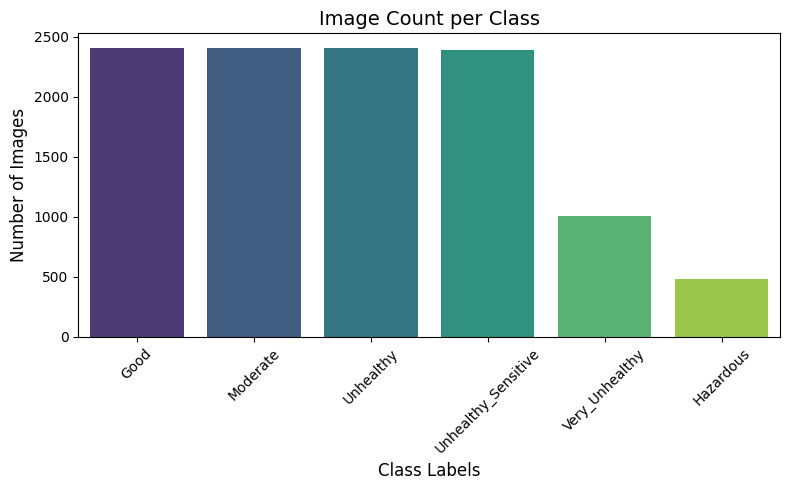

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This code displays a small gallery showing two random sample images from each air-quality class.
It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.
Useful for quick quality checks and understanding visual variation before model training.

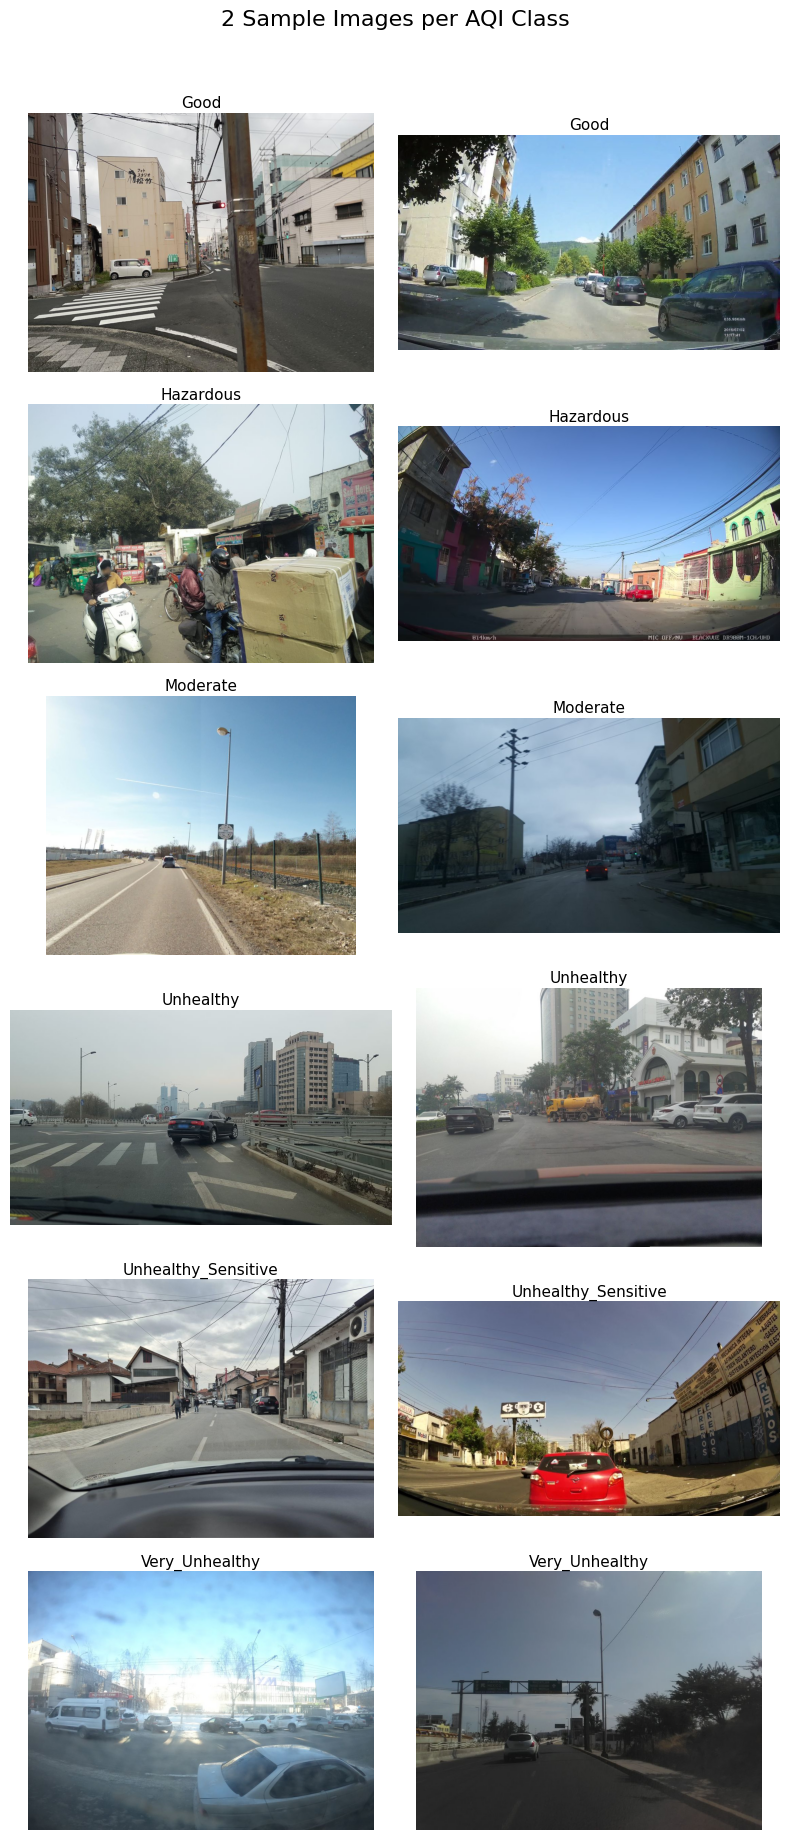

In [13]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

This function scans a dataset split directory (train/val/test), collects all image file paths along with their class labels, and returns them as a DataFrame. It also supports optional class filtering, allowing you to load only selected classes when needed.

In [14]:
def load_split(split_dir, selected_classes=None):
    file_paths, labels = [], []
    for class_name in os.listdir(split_dir):
        if selected_classes and class_name not in selected_classes:
            continue  
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            for image_name in os.listdir(class_dir):
                file_paths.append(os.path.join(class_dir, image_name))
                labels.append(class_name)
    return pd.DataFrame({"file_path": file_paths, "label": labels})


This block defines the PM2.5 air-quality classes, loads all images belonging to these categories, and prints both the total image count and per-class distribution. It helps verify that the dataset has been correctly loaded and filtered.

In [15]:
PM25_CLASSES = [
    "Good",
    "Moderate",
    "Unhealthy_Sensitive",
    "Unhealthy",
    "Very_Unhealthy",
    "Hazardous"
]

data = load_split(data_dir, selected_classes=PM25_CLASSES)

print("Total images:", len(data))
print(data["label"].value_counts())


Total images: 11103
label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


This block splits the dataset into train, validation, and test sets using stratified sampling to preserve class balance. First, 70% is allocated for training, and the remaining 30% is split evenly into validation and test sets. The sizes of each split are printed for verification.

In [16]:
from sklearn.model_selection import train_test_split

train_dataframe, temp_dataframe = train_test_split(
    data,
    test_size=0.30,
    stratify=data["label"],
    random_state=42
)

validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe,
    test_size=0.50,
    stratify=temp_dataframe["label"],
    random_state=42
)

print(len(train_dataframe))
print(len(validation_dataframe))
print(len(test_dataframe))


7772
1665
1666


This block defines a flexible dataset class used for both self-supervised BYOL training and supervised downstream tasks. It loads image file paths, applies the required transformations, and conditionally encodes labels when operating in labeled mode. During BYOL pretext training, the class returns two augmented views of the same image, while in supervised mode it returns a single transformed image along with its numeric label. This ensures a unified, consistent data-loading pipeline for all stages of the workflow.

In [17]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform, is_lb=False):
        self.file_paths = dataframe["file_path"].values
        self.transform = transform
        self.is_lb = is_lb

        if self.is_lb:
            self.labels = dataframe["label"].values
            self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(set(self.labels)))}
            self.labels = np.array([self.class_to_idx[lbl] for lbl in self.labels])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, index):
        image_path = self.file_paths[index]
        image = PIL.Image.open(image_path).convert("RGB")

        if self.is_lb:
            label = self.labels[index]
            image = self.transform(image)
            return image, label
        else:
            x0, x1 = self.transform(image)
            return x0, x1


This block creates the two augmented image views required for BYOL pretext training. Each view applies a different set of transformations (crop, color jitter, blur, normalization) to help the model learn stable and invariant feature representations.

In [18]:
byol_transform = BYOLTransform(
    view_1_transform=BYOLView1Transform(input_size=224, normalize=IMAGENET_NORMALIZE),
    view_2_transform=BYOLView2Transform(input_size=224, normalize=IMAGENET_NORMALIZE),
)


This block prepares the self-supervised training data by applying the BYOL dual-view transforms and wrapping the dataset in a DataLoader. It enables efficient batch loading, shuffling, and parallel processing for the pretext training stage.

In [19]:
training_dataset = ImageDataset(
    train_dataframe,
    transform=byol_transform,
    is_lb=False
)

dataloader = DataLoader(
    training_dataset,
    batch_size=training_batch,
    shuffle=True,
    drop_last=True,
    num_workers=2
)


This block defines a helper function to display paired BYOL views for randomly selected images. It shows how each image is transformed into two different augmented versions, helping verify that the dual-view augmentation pipeline is working correctly.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

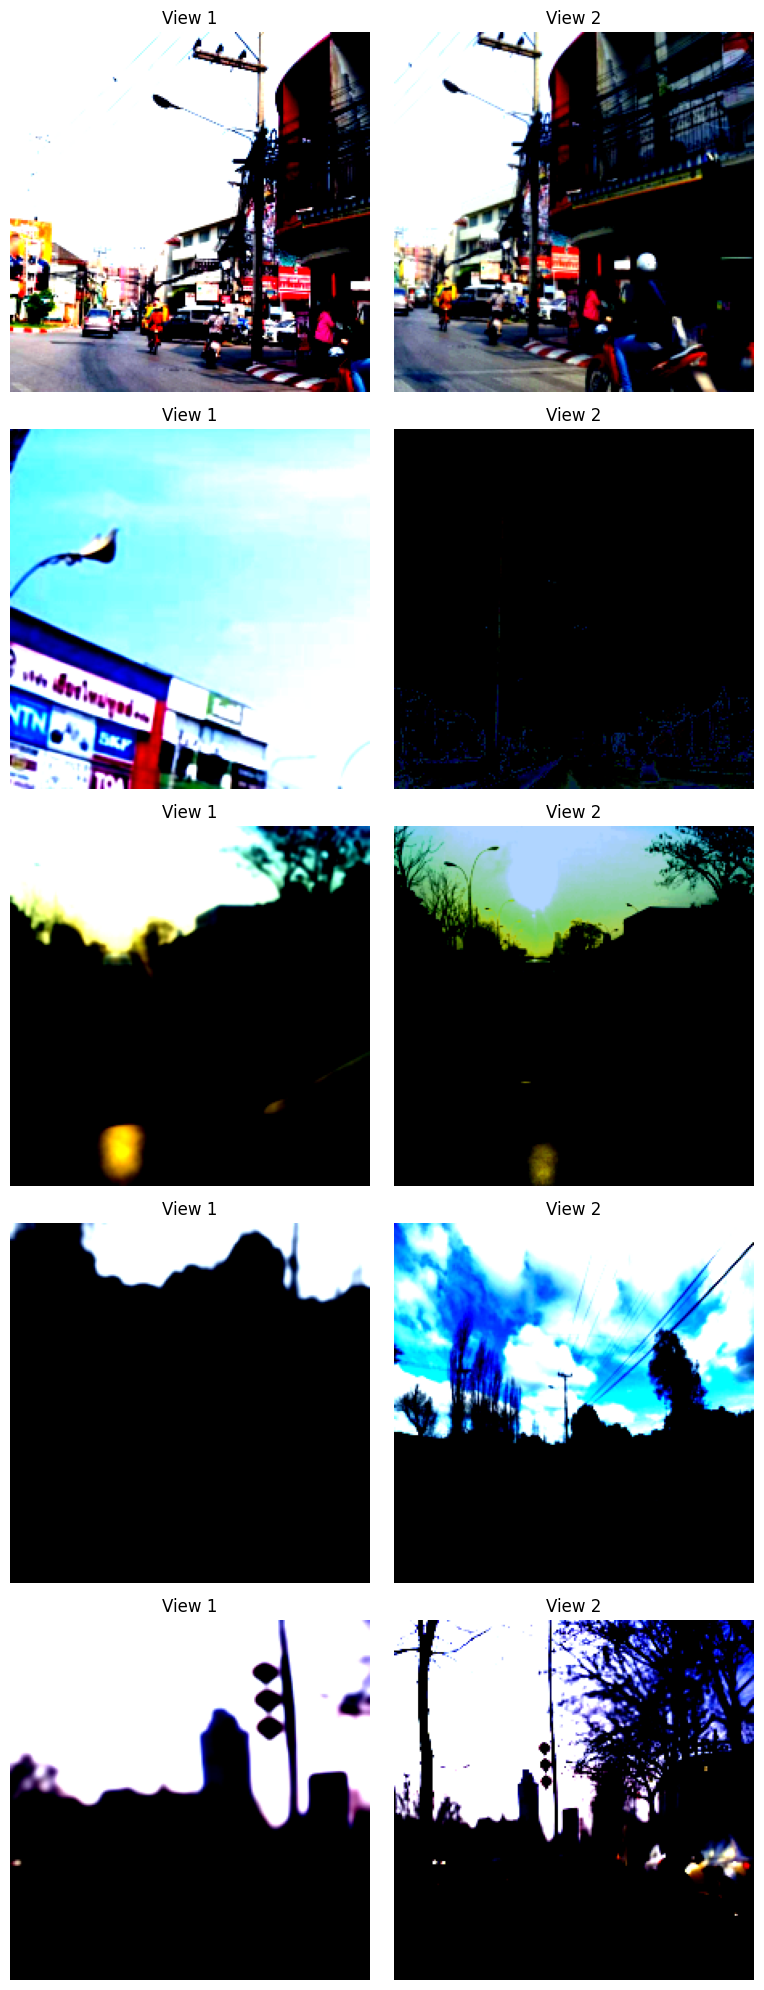

In [20]:
def visualize_model_views(dataset, num_imgs=5):
    fig, axes = plt.subplots(num_imgs, 2, figsize=(8, 4*num_imgs))

    random_indices = random.sample(range(len(dataset)), num_imgs)

    for i, idx in enumerate(random_indices):
        x0, x1 = dataset[idx]

        axes[i, 0].imshow(x0.permute(1,2,0).numpy())
        axes[i, 0].set_title("View 1")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(x1.permute(1,2,0).numpy())
        axes[i, 1].set_title("View 2")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

visualize_model_views(training_dataset, num_imgs=5)


This block defines the full BYOL architecture using a ResNet-50 encoder. It builds the online network with projection and prediction heads, creates a momentum (target) network via a frozen copy of the backbone and projection head, and sets up both forward passes required for BYOL training. The model is then moved to the selected device for pretext learning.

In [21]:
class BYOL(nn.Module):
    def __init__(self, backbone):
        super().__init__()

        self.backbone = backbone
        self.projection_head = BYOLProjectionHead(2048, 1024, 256)  # ★★★ ResNet50 = 2048-dim
        self.prediction_head = BYOLPredictionHead(256, 1024, 256)

        self.backbone_momentum = copy.deepcopy(self.backbone)
        self.projection_head_momentum = copy.deepcopy(self.projection_head)

        deactivate_requires_grad(self.backbone_momentum)
        deactivate_requires_grad(self.projection_head_momentum)

    def forward(self, x):
        y = self.backbone(x).flatten(start_dim=1)
        z = self.projection_head(y)
        p = self.prediction_head(z)
        return p

    def forward_momentum(self, x):
        y = self.backbone_momentum(x).flatten(start_dim=1)
        z = self.projection_head_momentum(y)
        z = z.detach()
        return z



resnet = torchvision.models.resnet50(weights=None) 
backbone = nn.Sequential(*list(resnet.children())[:-1])

model = BYOL(backbone)
model.to(device)


BYOL(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64, 25

This block installs THOP and uses it to measure the computational cost of the ResNet-50 backbone at 224×224 resolution. It calculates MACs, derives FLOPs, and reports total parameters—providing a clear summary of the model’s efficiency and resource requirements.

In [ ]:

!pip install thop >/dev/null

from thop import profile, clever_format

dummy_input = torch.randn(1, 3, 224, 224).to(device)

macs, params = profile(model.backbone, inputs=(dummy_input,), verbose=False)
macs, params = clever_format([macs, params], "%.3f")


float_macs = float(macs[:-1])   
gflops = float_macs * 2

print("\n[Complexity @224x224]")
print(f"MACs: {macs}")
print(f"GFLOPs: {gflops:.3f}G")
print(f"Params: {params}")



[Complexity @224x224]
MACs: 4.132G
GFLOPs: 8.264G
Params: 23.508M


This block sets up the Negative Cosine Similarity loss for BYOL and configures the LARS optimizer with the chosen learning rate, weight decay, and momentum for stable SSL training.

In [23]:
criterion = NegativeCosineSimilarity()
optimizer = LARS(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
    momentum=0.9,
)


This block handles the complete BYOL training process—loading previous checkpoints and loss logs, initializing AMP mixed-precision training, restoring optimizer/scaler states, and setting up safe resume logic. It then runs the full epoch loop with momentum updates, loss tracking, periodic checkpoint saving, and prints total training time. Designed to continue training seamlessly even after Kaggle interruptions.

In [ ]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()
loss_history = []

with open(loss_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss'])

print("Starting Training")
total_start_time = time.time()

for epoch in range(start_epoch, total_epochs):
    start_time = time.time()
    total_loss = 0

    momentum_val = cosine_schedule(epoch, total_epochs, 0.996, 1)
    
    for batch_data in dataloader:
        x0, x1 = batch_data
        x0 = x0.to(device)
        x1 = x1.to(device)

        with autocast():
            p0 = model(x0)
            z1 = model.forward_momentum(x1)

            p1 = model(x1)
            z0 = model.forward_momentum(x0)

            loss = 0.5 * (criterion(p0, z1) + criterion(p1, z0))

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()



        update_momentum(model.backbone, model.backbone_momentum, momentum_val)
        update_momentum(model.projection_head, model.projection_head_momentum, momentum_val)

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

    epoch_time = time.time() - start_time
    m = int(epoch_time // 60)
    s = int(epoch_time % 60)
    print(f"epoch: {epoch+1:02d}, loss: {avg_loss:.5f}, time: {m}m {s}s")


    with open(loss_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, avg_loss])


    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss
    }, checkpoint_path)


total_end_time = time.time()
duration = total_end_time - total_start_time
hours = duration // 3600
minutes = (duration % 3600) // 60
seconds = duration % 60

print("Training completed!")
print(f"Total training time: {hours}h {minutes}m {seconds}s")


Starting Training
epoch: 01, loss: -0.62780, time: 2m 6s
epoch: 02, loss: -0.72067, time: 2m 7s
epoch: 03, loss: -0.72528, time: 2m 5s
epoch: 04, loss: -0.74700, time: 2m 5s
epoch: 05, loss: -0.75470, time: 2m 6s
epoch: 06, loss: -0.76629, time: 2m 6s
epoch: 07, loss: -0.76271, time: 2m 5s
epoch: 08, loss: -0.76988, time: 2m 7s
epoch: 09, loss: -0.77602, time: 2m 9s
epoch: 10, loss: -0.76839, time: 2m 6s
epoch: 11, loss: -0.76328, time: 2m 7s
epoch: 12, loss: -0.76746, time: 2m 7s
epoch: 13, loss: -0.77069, time: 2m 6s
epoch: 14, loss: -0.76992, time: 2m 5s
epoch: 15, loss: -0.77392, time: 2m 7s
epoch: 16, loss: -0.78442, time: 2m 4s
epoch: 17, loss: -0.78980, time: 2m 6s
epoch: 18, loss: -0.79495, time: 2m 5s
epoch: 19, loss: -0.79756, time: 2m 5s
epoch: 20, loss: -0.78969, time: 2m 7s
epoch: 21, loss: -0.79557, time: 2m 4s
epoch: 22, loss: -0.79349, time: 2m 3s
epoch: 23, loss: -0.79105, time: 2m 4s
epoch: 24, loss: -0.79591, time: 2m 4s
epoch: 25, loss: -0.79377, time: 2m 4s
epoch: 

This block reads the saved loss.csv file and visualizes how the BYOL training loss changes across epochs. It helps verify training stability, detect convergence trends, and ensure the model is learning as expected.

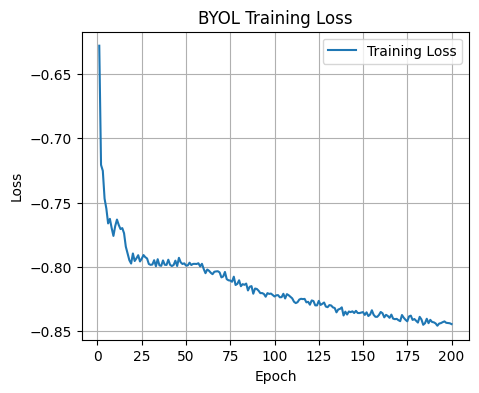

In [25]:
loss_df = pd.read_csv(loss_file)

plt.figure(figsize=(5,4))
plt.plot(loss_df['epoch'], loss_df['loss'], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BYOL Training Loss")
plt.grid(True)
plt.legend()
plt.show()


This block switches the model to evaluation mode, prepares a normalized transform, and builds a labeled dataset for embedding extraction. It then passes all images through the BYOL backbone to collect feature vectors and their labels, finally saving them as a .npz file for use in linear probing, shallow classifiers, and other downstream evaluations.

In [26]:
model.eval()

embedding_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

embedding_dataset = ImageDataset(train_dataframe, transform=embedding_transform, is_lb=True)
embedding_loader = DataLoader(embedding_dataset, batch_size=training_batch, shuffle=False)

def extract_embeddings(model, dataloader, device):
    embeddings = []
    labels_list = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = model.backbone(images).flatten(start_dim=1)
            embeddings.append(features.cpu())
            labels_list.append(labels.cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return embeddings, labels

embeddings, labels = extract_embeddings(model, embedding_loader, device)
np.savez(embedding_path, embeddings=embeddings, labels=labels)


This block applies t-SNE to reduce the high-dimensional BYOL embeddings to 2D and visualizes them with a scatter plot. It helps assess how well the learned features separate different PM2.5 classes in the embedding space.

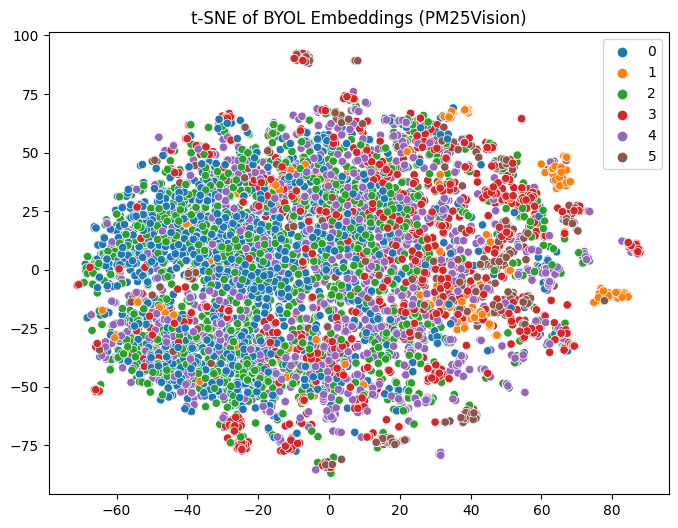

In [27]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1], hue=labels, palette="tab10")
plt.title("t-SNE of BYOL Embeddings (PM25Vision)")
plt.show()


This block performs KMeans clustering on the BYOL embeddings, computes the Silhouette Score to measure cluster quality, and visualizes the resulting clusters on the 2D t-SNE plot. It helps assess how well the learned features naturally group PM2.5 categories.

Silhouette Score: 0.064


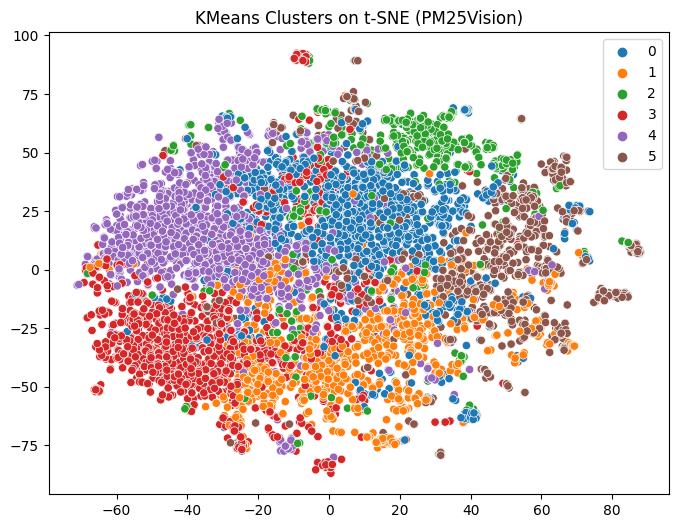

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

silhouette_avg = silhouette_score(embeddings, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.3f}")

plt.figure(figsize=(8,6))
sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1], hue=cluster_labels, palette="tab10")
plt.title("KMeans Clusters on t-SNE (PM25Vision)")
plt.show()
